In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [23]:
# Load the raw npz file
raw_data = np.load('../data/transformed_simulation_data.npz')
z_vals = raw_data['z_vals']
u_plot = raw_data['u_plot']

# z_vals contains [Rel Pos, Rel Vel, Abs Pos of M2, Abs Vel of M2]
columns = ['Input Force (u)', 'Rel Pos (z1)', 'Rel Vel (z2)', 'Abs Pos of M2 (z3)', 'Abs Vel of M2 (z4)']

# Create a DataFrame combining both raw arrays
# We use np.column_stack to attach the 1D u_plot alongside the 2D z_vals
df = pd.DataFrame(
    np.column_stack((u_plot, z_vals)),
    columns=columns
)

# Set the index name to represent Time Steps
df.index.name = 'Time Step'
display(df.head(10))


,Input Force (u),Rel Pos (z1),Rel Vel (z2),Abs Pos of M2 (z3),Abs Vel of M2 (z4)
Time Step,,,,,
0,0.993428,0.000000,0.000000,0.000000e+00,0.000000
1,0.993428,0.000196,0.039080,6.578013e-07,0.000197
2,0.993428,0.000777,0.076865,5.227087e-06,0.000781
3,0.993428,0.001730,0.113386,1.752287e-05,0.001740
4,0.993428,0.003041,0.148670,4.125689e-05,0.003066
5,0.993428,0.004699,0.182746,8.003968e-05,0.004749
6,0.993428,0.006692,0.215643,1.373827e-04,0.006777
7,0.993428,0.009008,0.247386,2.167003e-04,0.009142
8,0.993428,0.011636,0.278003,3.213117e-04,0.011834


In [24]:
# normalize the data 
z_mean, z_std = z_vals.mean(axis=0), z_vals.std(axis=0)
u_mean, u_std = u_plot.mean(), u_plot.std()

z_norm = (z_vals - z_mean) / (z_std + 1e-8)
u_norm = (u_plot - u_mean) / (u_std + 1e-8)

# convert to torch tensors
Z = torch.tensor(z_norm, dtype=torch.float32)
U = torch.tensor(u_norm, dtype=torch.float32).unsqueeze(1)

print(f"Data is normalized. Final shapes ready for model:")
print(f"Z Shape: {Z.shape} | U Shape: {U.shape}")

Data is normalized. Final shapes ready for model:
Z Shape: torch.Size([20000, 4]) | U Shape: torch.Size([20000, 1])


In [25]:
# define the model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Memory Update Weights
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.W_uh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        # State Prediction Weights
        self.W_hx = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_x = nn.Parameter(torch.zeros(output_size))
    
    def forward(self, combined_u_seq):
        # get sequence length
        seq_len = combined_u_seq.shape[0]

        # initialize hidden state
        h_k = torch.zeros(self.hidden_size, device=combined_u_seq.device)

        # initialize list to store predictions
        y_pred = []

        # loop through the sequence
        for k in range(seq_len):
            # contains [x1, v1, x2, v2, force]
            step_data = combined_u_seq[k]

            # update hidden state
            h_k = torch.relu(h_k @ self.W_hh + step_data @ self.W_uh + self.b_h)

            # predict next state
            y_k = h_k @ self.W_hx + self.b_x

            # store prediction
            y_pred.append(y_k)

        # convert list to tensor
        y_pred = torch.stack(y_pred)

        return y_pred

# Training with `hidden_size=64` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=5, hidden_size=64, output_size=4).to(device) # changed this to 5 (4 current states + 1 input force)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len - 1) # -1 cuz we need more space to get the traget one step in the future
        end_idx = start_idx + seq_len
        
        # Get current states and inputs
        U_curr = U[start_idx:end_idx].to(device)
        Z_curr = Z[start_idx:end_idx].to(device)
        
        # combine current state and input 
        combined_input = torch.cat((Z_curr, U_curr), dim=1)

        # NEW: get next states (target shifted by +1)
        Z_target = Z[start_idx + 1: end_idx + 1].to(device)

        # forward pass
        Z_pred_chunk = model(combined_input)
        
        # calculate loss
        loss = criterion(Z_pred_chunk, Z_target)
        loss = loss/batch_size
        
        # backpropagate and update
        loss.backward()
        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 0.9982
Epoch 20/1000, Average Batch Loss: 1.0503
Epoch 30/1000, Average Batch Loss: 0.4774
Epoch 40/1000, Average Batch Loss: 0.9812
Epoch 50/1000, Average Batch Loss: 1.0121
Epoch 60/1000, Average Batch Loss: 1.0306
Epoch 70/1000, Average Batch Loss: 0.4643
Epoch 80/1000, Average Batch Loss: 0.7415
Epoch 90/1000, Average Batch Loss: 0.8670
Epoch 100/1000, Average Batch Loss: 0.8755
Epoch 110/1000, Average Batch Loss: 0.6074
Epoch 120/1000, Average Batch Loss: 0.5307
Epoch 130/1000, Average Batch Loss: 0.6071
Epoch 140/1000, Average Batch Loss: 0.4072
Epoch 150/1000, Average Batch Loss: 0.6206
Epoch 160/1000, Average Batch Loss: 0.2747
Epoch 170/1000, Average Batch Loss: 0.3144
Epoch 180/1000, Average Batch Loss: 0.4212
Epoch 190/1000, Average Batch Loss: 0.2656
Epoch 200/1000, Average Batch Loss: 0.2507
Epoch 210/1000, Average Batch Loss: 0.2458
Epoch 220/1000, Average Batch Loss: 0.2273
Epoch 230/1000, Average Batch Loss: 0.1136
Ep

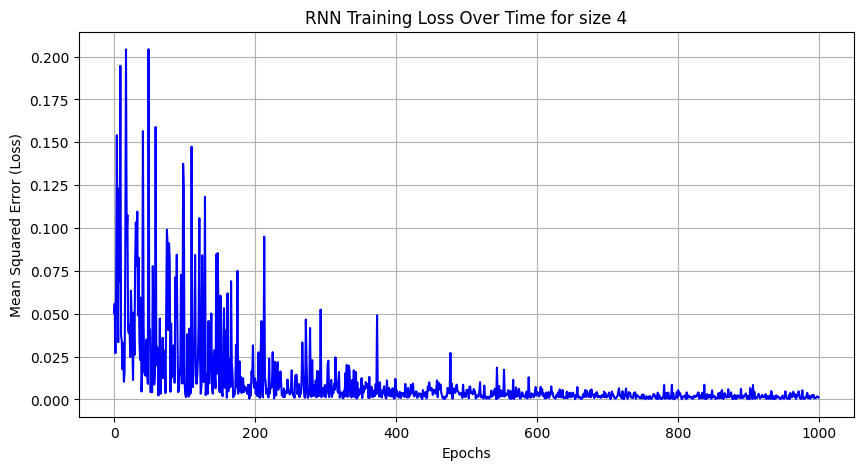

In [27]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 4')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN in Closed-Loop Autoregressive for Size 64


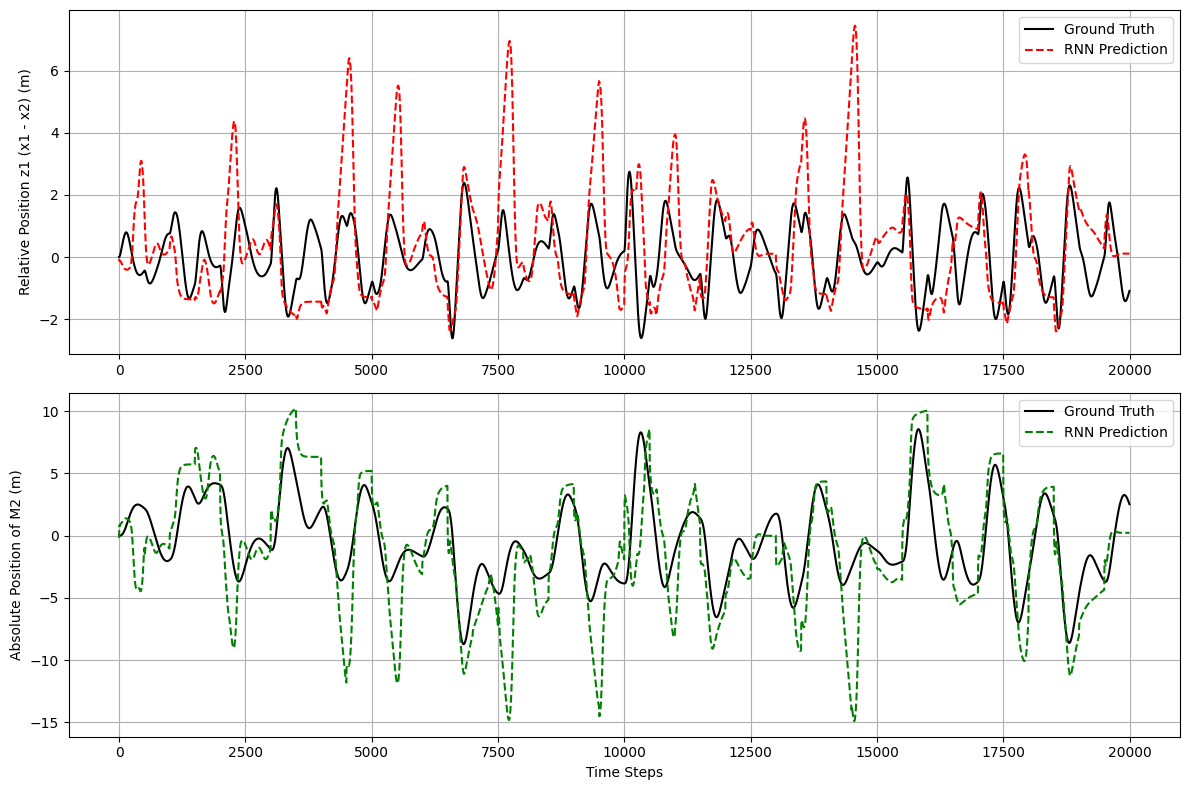

In [ ]:
# evaluate the model
print("Evaluating trained RNN in Closed-Loop Autoregressive for Size 64")
model.eval()

with torch.no_grad():
    continous_pred = []
    current_state = Z[0].to(device)

    # init hidden memory for all 20,000 steps
    h_k = torch.zeros(model.hidden_size, device=device)

    for k in range(len(U)):
        # get true input for this time step
        u_k = U[k].to(device)

        # combine current input with current force
        step_data = torch.cat((current_state, u_k))

        # forward pass this time step
        h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
        next_state_pred = h_k @ model.W_hx + model.b_x

        # save this prediction
        continous_pred.append(next_state_pred)

        # feedback loop
        current_state = next_state_pred

    Y_pred_norm = torch.stack(continous_pred)
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * z_std + z_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Rel Pos (z1)
plt.subplot(2, 1, 1)
plt.plot(z_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Relative Position z1 (x1 - x2) (m)')
plt.legend()
plt.grid(True)

# Plot Absolute Position of M2 (z3)
plt.subplot(2, 1, 2)
plt.plot(z_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Absolute Position of M2 (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Try with same epochs (1000) but different hidden size (4)

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=5, hidden_size=4, output_size=4).to(device) # changed this to 5 (4 current states + 1 input force)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len - 1) # -1 cuz we need more space to get the traget one step in the future
        end_idx = start_idx + seq_len
        
        # Get current states and inputs
        U_curr = U[start_idx:end_idx].to(device)
        Z_curr = Z[start_idx:end_idx].to(device)
        
        # combine current state and input 
        combined_input = torch.cat((Z_curr, U_curr), dim=1)

        # NEW: get next states (target shifted by +1)
        Z_target = Z[start_idx + 1: end_idx + 1].to(device)

        # forward pass
        Z_pred_chunk = model(combined_input)
        
        # calculate loss
        loss = criterion(Z_pred_chunk, Z_target)
        loss = loss/batch_size
        
        # backpropagate and update
        loss.backward()
        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 0.8065
Epoch 20/1000, Average Batch Loss: 0.6926
Epoch 30/1000, Average Batch Loss: 1.3744
Epoch 40/1000, Average Batch Loss: 0.7917
Epoch 50/1000, Average Batch Loss: 0.8874
Epoch 60/1000, Average Batch Loss: 1.0403
Epoch 70/1000, Average Batch Loss: 1.2151
Epoch 80/1000, Average Batch Loss: 0.7575
Epoch 90/1000, Average Batch Loss: 0.8579
Epoch 100/1000, Average Batch Loss: 0.8992
Epoch 110/1000, Average Batch Loss: 0.7099
Epoch 120/1000, Average Batch Loss: 1.2965
Epoch 130/1000, Average Batch Loss: 1.0301
Epoch 140/1000, Average Batch Loss: 0.8076
Epoch 150/1000, Average Batch Loss: 0.9603
Epoch 160/1000, Average Batch Loss: 1.0297
Epoch 170/1000, Average Batch Loss: 1.0688
Epoch 180/1000, Average Batch Loss: 0.8497
Epoch 190/1000, Average Batch Loss: 1.0269
Epoch 200/1000, Average Batch Loss: 1.0042
Epoch 210/1000, Average Batch Loss: 0.7531
Epoch 220/1000, Average Batch Loss: 1.1331
Epoch 230/1000, Average Batch Loss: 1.3600
Ep

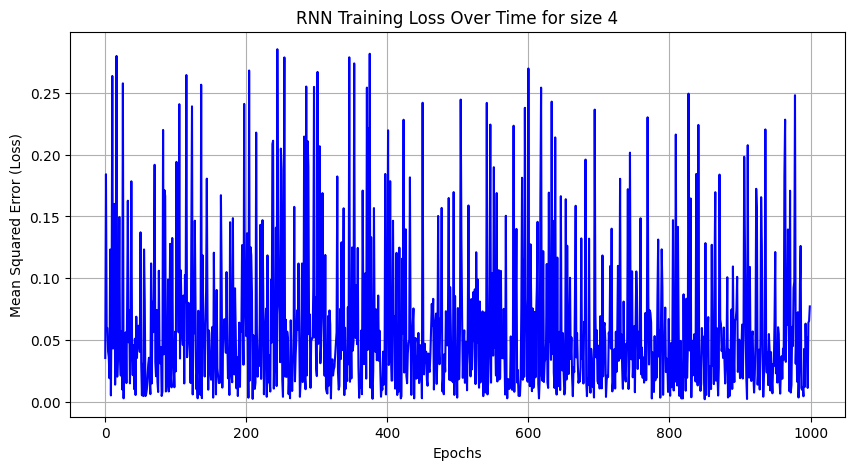

In [30]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 4')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN in Closed-Loop Autoregressive for Size 64


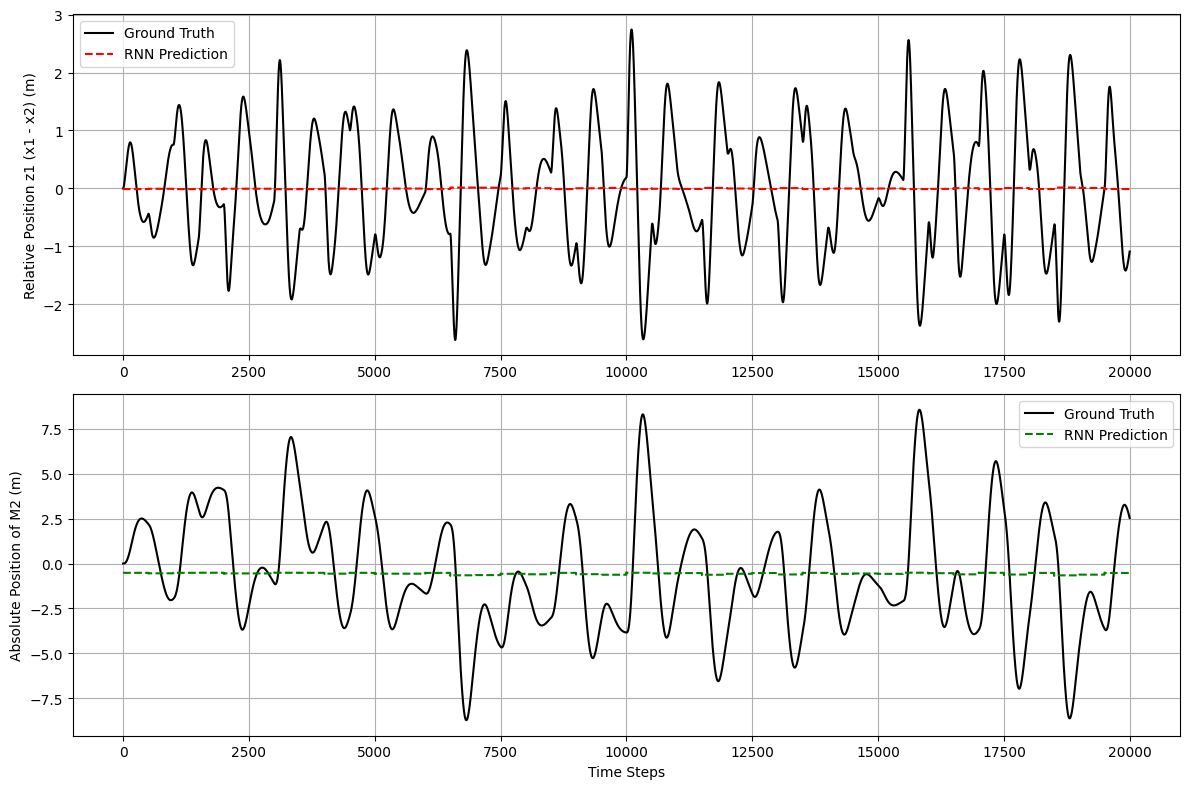

In [31]:
# evaluate the model
print("Evaluating trained RNN in Closed-Loop Autoregressive for Size 64")
model.eval()

with torch.no_grad():
    continous_pred = []
    current_state = Z[0].to(device)

    # init hidden memory for all 20,000 steps
    h_k = torch.zeros(model.hidden_size, device=device)

    for k in range(len(U)):
        # get true input for this time step
        u_k = U[k].to(device)

        # combine current input with current force
        step_data = torch.cat((current_state, u_k))

        # forward pass this time step
        h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
        next_state_pred = h_k @ model.W_hx + model.b_x

        # save this prediction
        continous_pred.append(next_state_pred)

        # feedback loop
        current_state = next_state_pred

    Y_pred_norm = torch.stack(continous_pred)
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * z_std + z_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Rel Pos (z1)
plt.subplot(2, 1, 1)
plt.plot(z_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Relative Position z1 (x1 - x2) (m)')
plt.legend()
plt.grid(True)

# Plot Absolute Position of M2 (z3)
plt.subplot(2, 1, 2)
plt.plot(z_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Absolute Position of M2 (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Try with hidden size (8) and epochs (1000)

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=5, hidden_size=8, output_size=4).to(device) # changed this to 5 (4 current states + 1 input force)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 1000
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len - 1) # -1 cuz we need more space to get the traget one step in the future
        end_idx = start_idx + seq_len
        
        # Get current states and inputs
        U_curr = U[start_idx:end_idx].to(device)
        Z_curr = Z[start_idx:end_idx].to(device)
        
        # combine current state and input 
        combined_input = torch.cat((Z_curr, U_curr), dim=1)

        # NEW: get next states (target shifted by +1)
        Z_target = Z[start_idx + 1: end_idx + 1].to(device)

        # forward pass
        Z_pred_chunk = model(combined_input)
        
        # calculate loss
        loss = criterion(Z_pred_chunk, Z_target)
        loss = loss/batch_size
        
        # backpropagate and update
        loss.backward()
        batch_loss += (loss.item() * batch_size)
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/1000, Average Batch Loss: 1.0498
Epoch 20/1000, Average Batch Loss: 0.7849
Epoch 30/1000, Average Batch Loss: 1.2002
Epoch 40/1000, Average Batch Loss: 0.9512
Epoch 50/1000, Average Batch Loss: 0.8327
Epoch 60/1000, Average Batch Loss: 0.6919
Epoch 70/1000, Average Batch Loss: 1.2915
Epoch 80/1000, Average Batch Loss: 0.7796
Epoch 90/1000, Average Batch Loss: 1.1098
Epoch 100/1000, Average Batch Loss: 0.6279
Epoch 110/1000, Average Batch Loss: 1.0907
Epoch 120/1000, Average Batch Loss: 0.8401
Epoch 130/1000, Average Batch Loss: 0.8775
Epoch 140/1000, Average Batch Loss: 1.1775
Epoch 150/1000, Average Batch Loss: 0.7750
Epoch 160/1000, Average Batch Loss: 0.7795
Epoch 170/1000, Average Batch Loss: 1.0449
Epoch 180/1000, Average Batch Loss: 1.2525
Epoch 190/1000, Average Batch Loss: 0.5929
Epoch 200/1000, Average Batch Loss: 0.8697
Epoch 210/1000, Average Batch Loss: 0.9799
Epoch 220/1000, Average Batch Loss: 0.8541
Epoch 230/1000, Average Batch Loss: 0.7423
Ep

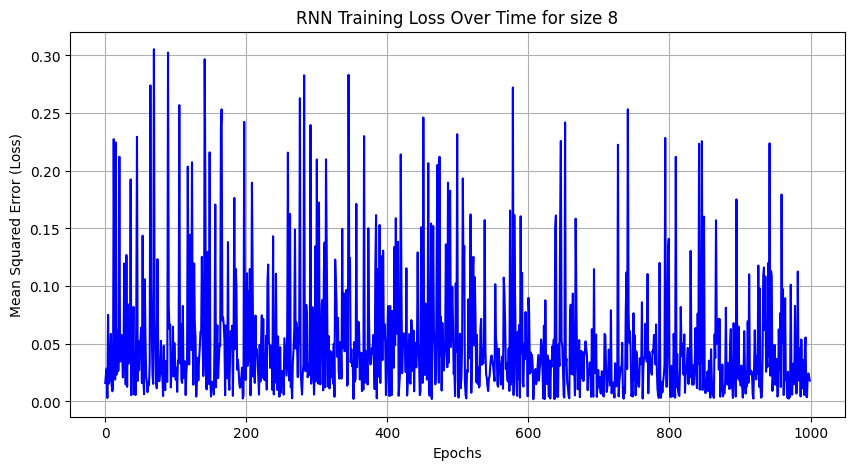

In [35]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 8')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN in Closed-Loop Autoregressive for Size 8


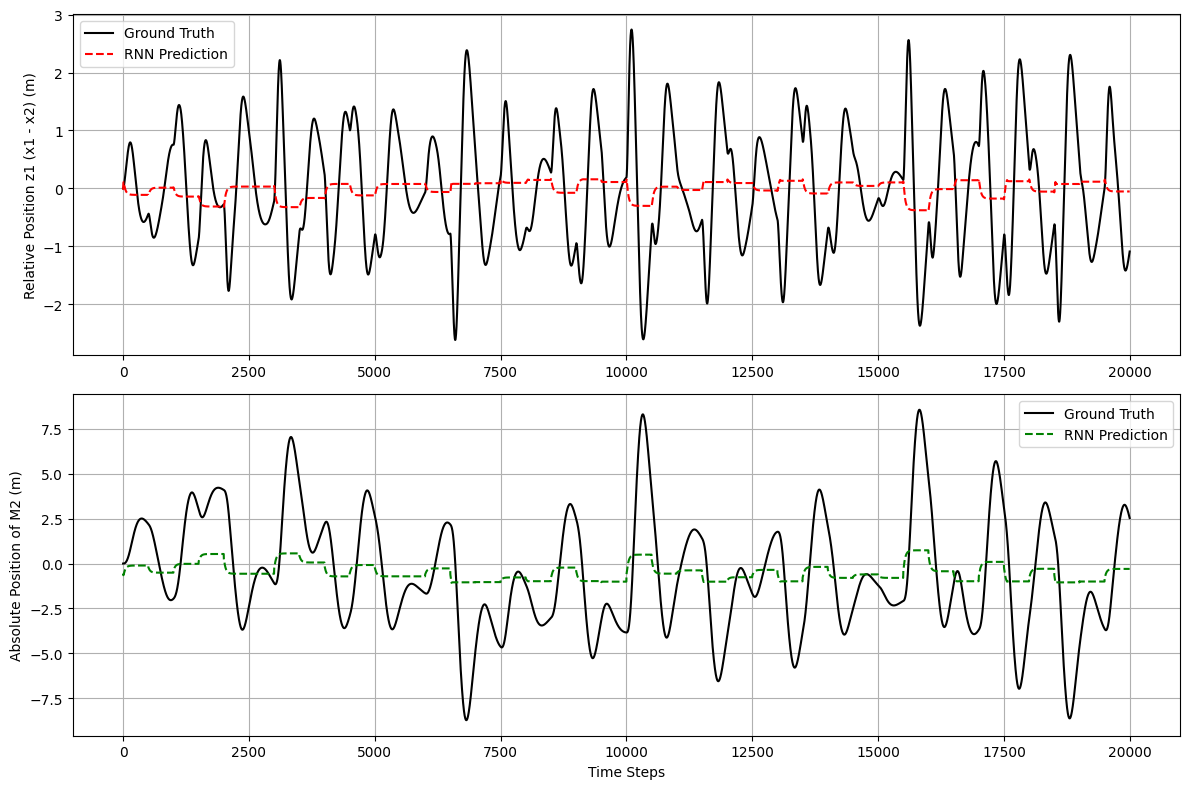

In [36]:
# evaluate the model
print("Evaluating trained RNN in Closed-Loop Autoregressive for Size 8")
model.eval()

with torch.no_grad():
    continous_pred = []
    current_state = Z[0].to(device)

    # init hidden memory for all 20,000 steps
    h_k = torch.zeros(model.hidden_size, device=device)

    for k in range(len(U)):
        # get true input for this time step
        u_k = U[k].to(device)

        # combine current input with current force
        step_data = torch.cat((current_state, u_k))

        # forward pass this time step
        h_k = torch.relu(h_k @ model.W_hh + step_data @ model.W_uh + model.b_h)
        next_state_pred = h_k @ model.W_hx + model.b_x

        # save this prediction
        continous_pred.append(next_state_pred)

        # feedback loop
        current_state = next_state_pred

    Y_pred_norm = torch.stack(continous_pred)
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * z_std + z_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Rel Pos (z1)
plt.subplot(2, 1, 1)
plt.plot(z_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Relative Position z1 (x1 - x2) (m)')
plt.legend()
plt.grid(True)

# Plot Absolute Position of M2 (z3)
plt.subplot(2, 1, 2)
plt.plot(z_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Absolute Position of M2 (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()